In [1]:
import dnois
from dnois.optics import rt
import matplotlib.pyplot as plt
import numpy as np
import scipy
import torch

import conf
import apparaturs
import sim
import utils

In [2]:
torch.set_grad_enabled(False)
utils.overwrite_dnois_ray_march()

In [3]:
n_order = (5, 5)  #级次数量

In [4]:
rcwa_t = scipy.io.loadmat('../data/RCWA/0612-back2d/t.mat')['results']  #(11, 37, 25, 4)
# 最后一维6表示两个完全相同的方向向量，因此只取前三个值即可
rcwa_k = scipy.io.loadmat('../data/RCWA/0612-back2d/k.mat')['results']  #(11, 37, 25, 6)

In [5]:
rcwa_t.shape

(1, 17, 169, 2, 2)

In [5]:
in_mode = 0  #0:TE,1:TM
out_mode = 0  #0:TE,1:TM
complex_t = rcwa_t[..., in_mode * 2 + out_mode]  #(11, 37, 25)
complex_t[..., :10] = -complex_t[..., :10]
transmittance = np.abs(complex_t)
phase_shift = np.angle(complex_t)

out_d = rcwa_k[..., in_mode * 3:in_mode * 3 + 3]  #(11, 37, 25, 3)
# RCWA中坐标系的XZ轴恰与DNOIS中的相反
out_d[..., [0, 2]] = -out_d[..., [0, 2]]
# RCWA计算的是基底中的方向，需要换算到空气中
out_d = utils.d_in_air(out_d)

In [6]:
sq = apparaturs.layout3(transmittance, phase_shift, out_d)
print(sq)

CoaxialSurfaceSequence(
  (0): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.005m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.0008749m)
    (context): CoaxialContext(distance=0.005m)
  )
  (1): CustomizedGrating(
    material=vacuum, reflective=False
    (aperture): CircularAperture(radius=0.005m)
    (context): CoaxialContext(distance=0.005m)
  )
  (2): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.00625m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.012906m)
    (context): CoaxialContext(distance=0.00625m)
  )
  (3): CircularStop(
    material=vacuum, reflective=False
    (aperture): CircularAperture(radius=0.01m)
    (context): CoaxialContext(distance=0.0625m)
  )
  (4): ThinLens(
    material=vacuum, reflective=False,
    fl1=0.0625m, fl2=identical to fl1
    (aperture): CircularAperture(radius=0.0125m)
    (context): CoaxialContext(distance=0.0625m)
  )
)


In [7]:
resolution = 256
image_width = 0.1e-3
sensor = dnois.sensor.Sensor(resolution, image_width / resolution)
optics = rt.CoaxialRayTracing(sq, sensor, wl=conf.wl, depth=sq.first.fl1).double()

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='$z/m$', ylabel='$y/m$'>)

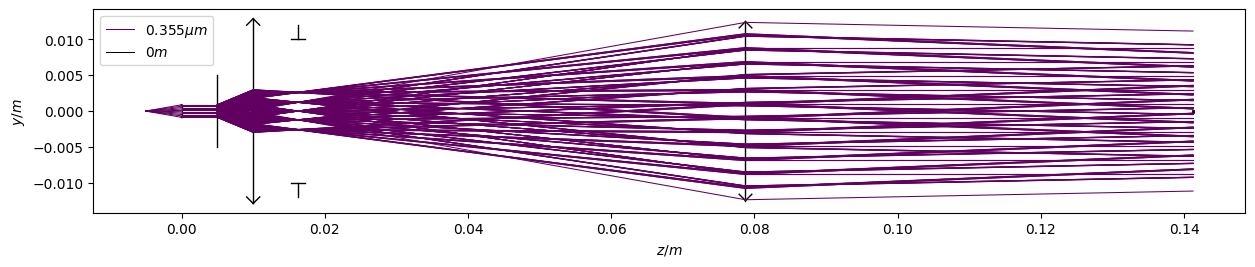

In [8]:
optics.plot_cross_section(height=0., init_rays=10)

# 成像模拟
## 单点

In [9]:
sampling_size = 128
point = optics.new_tensor([0, 0, -optics.depth.squeeze().item()]).unsqueeze(0)
ray_in, ray_out = sim.trace(optics, sampling_size, point, conf.wl)

D:\Code\dnois\src\dnois\optics\rt\surf.py:339: UserWarning: ThinLens does not support coherent ray tracing currently
  warnings.warn(f'{self.__class__.__name__} does not support coherent ray tracing currently')


In [10]:
grating = sq[1]
interpolators = sim.make_interpolators(ray_out, 1, grating.n_order)

In [11]:
y, x = dnois.utils.grid(sensor.resolution, sensor.pixel_size, symmetric=True, device='cpu')
y = -y
# x=x.contiguous()-5e-3
interpolated_field = sim.interpolate(interpolators, x, y)

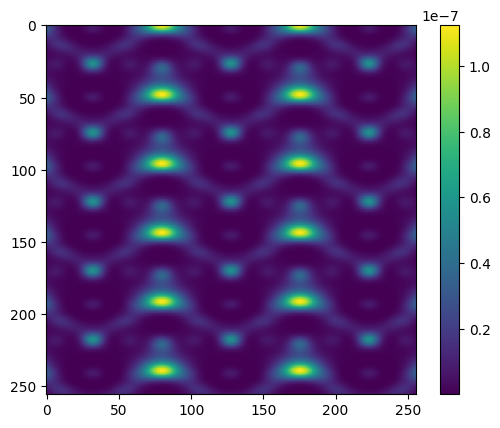

In [12]:
fig, ax = plt.subplots()
im = ax.imshow(dnois.torch.abs2(interpolated_field).cpu().numpy())
# ax.set(xticks=[], yticks=[])
fig.colorbar(im, ax=ax)

## 面光源

In [14]:
radius = 0.5e-3
depth = optics.depth.squeeze().item()

In [15]:
angles = torch.arange(8) * np.pi / 4
points = torch.stack([
    optics.new_tensor([0, 0, -depth]),
    *torch.stack([angles.cos() * radius / 5, angles.sin() * radius / 5, torch.full_like(angles, -depth)], -1).unbind(),
    *torch.stack([angles.cos() * radius, angles.sin() * radius, torch.full_like(angles, -depth)], -1).unbind(),
]).unsqueeze(1)  #(N_s,1,3)
n_s = points.size(0)
entry_points = optics.first.sample('rect', sampling_size, sampling_size)  #(spp, 3)
n_spp = entry_points.size(0)
print(f'{n_spp=}')
intensity = 1 / n_spp
ray_in = rt.BatchedRay(points, entry_points - point, conf.wl, init_opl=0, init_intensity=intensity)
ray_out = optics.trace_ray(ray_in)  #(N_s,spp)

n_spp=12892


In [16]:
grating = sq[1]
position = ray_out.o.reshape(n_s, grating.n_order, -1, 3)[..., :2]  #(N_s, N_order, spp, 2)
valid = ray_out.valid.reshape(n_s, grating.n_order, -1)  #(N_s, N_order, spp)
position = [
    [p[v] for p, v in zip(p1.unbind(), v1.unbind()) if v.any()]
    for p1, v1 in zip(position.unbind(), valid.unbind())
]  #(N_s, N_order, spp', 2)
value = torch.stack(
    [ray_out.intensity.sqrt(), ray_out.opl * dnois.k(ray_out.wl)], -1
).reshape(n_s, grating.n_order, -1, 2)  #(N_s, N_order, spp, 2)
value = [
    [val[v] for val, v in zip(val1.unbind(), v1.unbind()) if v.any()]
    for val1, v1 in zip(value.unbind(), valid.unbind())
]  #(N_s, N_order, spp', 2)
interpolators = [
    [
        utils.none_interpolator(p.detach().cpu().numpy(), v.detach().cpu().numpy(), 0.)
        for p, v in zip(p1, v1)
    ]
    for p1, v1 in zip(position, value)
]

In [17]:
y, x = dnois.utils.grid(sensor.resolution, sensor.pixel_size, symmetric=True, device='cpu')
y = -y
interpolated = [
    [utils.none_interpolate(intp, point, x, y) for intp in intp1]
    for intp1 in interpolators
]  #(H,W,2)

In [18]:
# plt.imshow(interpolated[2][..., 1].cpu().numpy())
# plt.colorbar()

In [19]:
interpolated_field = [
    [field[..., 0] * dnois.expi(field[..., 1]) for field in intp1 if field is not None]
    for intp1 in interpolated
]
interpolated_field = sum([sum(intp).abs().square() for intp in interpolated_field])  #(H,W)

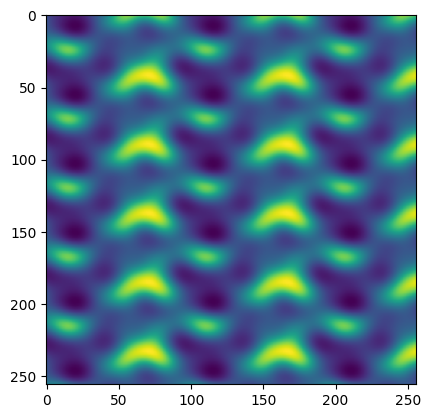

In [23]:
fig, ax = plt.subplots()
ax.imshow(dnois.torch.abs2(interpolated_field).cpu().numpy())
# ax.set(xticks=[], yticks=[])
# plt.colorbar()

[Text(0.5, 0, 'x/um')]

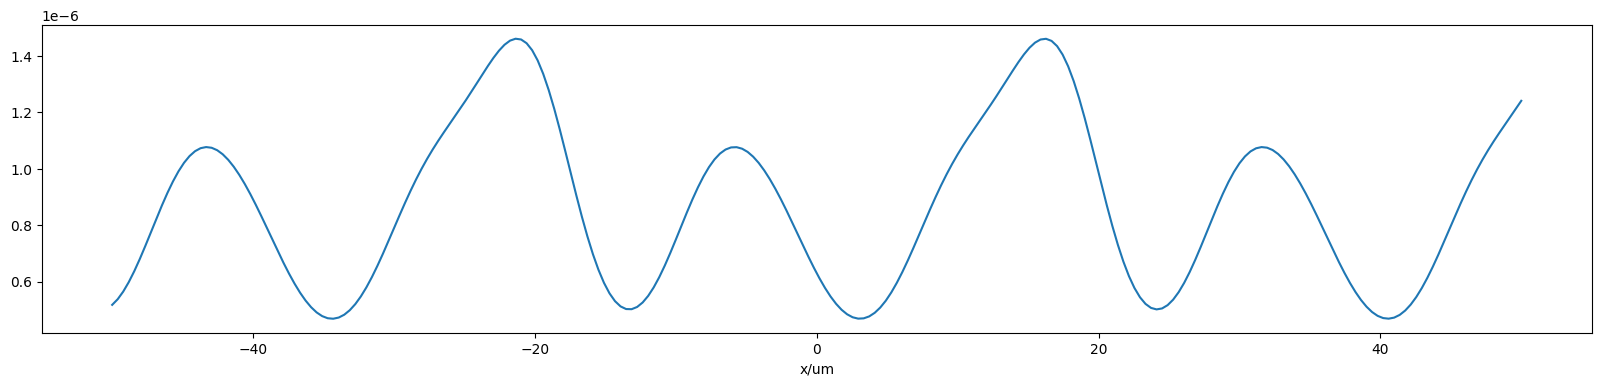

In [21]:
fig, ax = plt.subplots(figsize=(20, 4))
x = np.linspace(-sensor.w / 2, sensor.w / 2, sensor.res_w) * 1e6
ax.plot(x, (interpolated_field[sensor.res_h // 2].abs().square().cpu().numpy()))
# ax.plot(x, (interpolated_field.angle()[sensor.res_h//2].cpu().numpy()))
ax.set(xlabel='x/um')